# 10. 실제 모델 추론결과 자동 평가 리포트

## 목표
- 모델 추론 결과 파일(`CSV` 또는 `JSON`)을 입력받아
- IoU 기반 객체검출 성능을 자동 계산하고
- mAP 리포트/클래스별 분석/오류 샘플을 저장합니다.

---

## 입력 포맷

### CSV 예시
| image_id | class_id | conf | x1 | y1 | x2 | y2 |
|---------|----------|------|----|----|----|----|
| light_01_xxx | 2 | 0.87 | 0.11 | 0.22 | 0.19 | 0.30 |

### JSON 예시
```json
[
  {"image_id": "light_01_xxx", "class_id": 2, "conf": 0.87, "bbox": [0.11, 0.22, 0.19, 0.30]}
]
```

In [1]:
from pathlib import Path
from collections import defaultdict
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "auto_eval_report"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper",
}

IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)

# 사용자가 바꿔서 실행할 설정
EVAL_SPLIT = "test"
MAX_IMAGES = 400
PRED_PATH = PROJECT_ROOT / "predictions" / "detections.csv"  # .csv 또는 .json

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)
print("PRED_PATH:", PRED_PATH)

DATA_ROOT: C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset\pcb-defect-dataset
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\auto_eval_report
PRED_PATH: C:\MyCursorLab\10_프로젝트\predictions\detections.csv


## 1) GT 로드 및 유틸 함수

In [2]:
def yolo_to_xyxy(cx, cy, w, h):
    return (cx - w/2, cy - h/2, cx + w/2, cy + h/2)


def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    return inter / (area_a + area_b - inter + 1e-12)


def load_gt(split="test", max_images=400):
    gt = defaultdict(list)
    img_dir = DATA_ROOT / split / "images"
    lbl_dir = DATA_ROOT / split / "labels"

    for img_path in sorted(img_dir.glob("*.jpg"))[:max_images]:
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue

        text = lbl_path.read_text(encoding="utf-8").strip()
        if not text:
            continue

        for line in text.splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            cls, cx, cy, w, h = map(float, p)
            cls = int(cls)
            if cls not in CLASS_NAMES:
                continue
            gt[img_path.stem].append({
                "class_id": cls,
                "bbox": yolo_to_xyxy(cx, cy, w, h),
            })
    return gt

gt = load_gt(split=EVAL_SPLIT, max_images=MAX_IMAGES)
print("GT images:", len(gt))
print("GT boxes :", sum(len(v) for v in gt.values()))

GT images: 281
GT boxes : 581


## 2) Prediction 파일 로더 (CSV/JSON 자동 지원)

In [3]:
def normalize_bbox_row(x1, y1, x2, y2):
    x1, y1, x2, y2 = float(x1), float(y1), float(x2), float(y2)
    x1, y1 = max(0.0, x1), max(0.0, y1)
    x2, y2 = min(1.0, x2), min(1.0, y2)
    if x2 <= x1:
        x2 = min(1.0, x1 + 1e-3)
    if y2 <= y1:
        y2 = min(1.0, y1 + 1e-3)
    return (x1, y1, x2, y2)


def load_predictions(pred_path: Path):
    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction file not found: {pred_path}")

    preds = []
    suffix = pred_path.suffix.lower()

    if suffix == ".csv":
        df = pd.read_csv(pred_path)
        required = {"image_id", "class_id", "conf", "x1", "y1", "x2", "y2"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"CSV missing columns: {missing}")

        for _, r in df.iterrows():
            cid = int(r["class_id"])
            if cid not in CLASS_NAMES:
                continue
            preds.append({
                "image_id": str(r["image_id"]),
                "class_id": cid,
                "conf": float(r["conf"]),
                "bbox": normalize_bbox_row(r["x1"], r["y1"], r["x2"], r["y2"]),
            })

    elif suffix == ".json":
        data = json.loads(pred_path.read_text(encoding="utf-8"))
        for item in data:
            cid = int(item["class_id"])
            if cid not in CLASS_NAMES:
                continue
            x1, y1, x2, y2 = item["bbox"]
            preds.append({
                "image_id": str(item["image_id"]),
                "class_id": cid,
                "conf": float(item["conf"]),
                "bbox": normalize_bbox_row(x1, y1, x2, y2),
            })
    else:
        raise ValueError("지원 형식은 .csv 또는 .json 입니다.")

    return preds

# 파일이 없으면 데모 예측 생성 (학습용)
def make_demo_predictions_from_gt(gt_dict, seed=777):
    rng = np.random.default_rng(seed)

    def clamp01(x):
        return max(0.0, min(1.0, x))

    def jitter(box, s=0.025):
        x1, y1, x2, y2 = box
        d = rng.normal(0, s, 4)
        nx1, ny1 = clamp01(x1+d[0]), clamp01(y1+d[1])
        nx2, ny2 = clamp01(x2+d[2]), clamp01(y2+d[3])
        if nx2 <= nx1: nx2 = clamp01(nx1 + 0.01)
        if ny2 <= ny1: ny2 = clamp01(ny1 + 0.01)
        return (nx1, ny1, nx2, ny2)

    def rbox():
        x1, y1 = rng.uniform(0, 0.8, 2)
        w, h = rng.uniform(0.04, 0.24, 2)
        return (x1, y1, clamp01(x1+w), clamp01(y1+h))

    out = []
    for image_id, objs in gt_dict.items():
        for o in objs:
            if rng.random() < 0.87:
                out.append({
                    "image_id": image_id,
                    "class_id": o["class_id"],
                    "conf": float(rng.uniform(0.55, 0.99)),
                    "bbox": jitter(o["bbox"], s=0.02),
                })
        for _ in range(rng.integers(0, 3)):
            out.append({
                "image_id": image_id,
                "class_id": int(rng.integers(0, 6)),
                "conf": float(rng.uniform(0.2, 0.85)),
                "bbox": rbox(),
            })
    return out

try:
    preds = load_predictions(PRED_PATH)
    print(f"외부 prediction 로드 성공: {len(preds)}개")
except Exception as e:
    print("외부 prediction 로드 실패/미지정 -> 데모 예측 사용")
    print("사유:", e)
    preds = make_demo_predictions_from_gt(gt)
    print(f"데모 prediction 생성: {len(preds)}개")

pd.DataFrame(preds).head()

외부 prediction 로드 실패/미지정 -> 데모 예측 사용
사유: Prediction file not found: C:\MyCursorLab\10_프로젝트\predictions\detections.csv
데모 prediction 생성: 778개


,image_id,class_id,conf,bbox
0,l_light_01_missing_hole_04_2_600,2,0.718439,"(0.33163148053135316, 0.0966772661716371, 0.41..."
1,l_light_01_missing_hole_04_2_600,2,0.787421,"(0.18716163196300867, 0.38660967316839406, 0.2..."
2,l_light_01_missing_hole_04_2_600,4,0.641960,"(0.5612231769656264, 0.08420825906473217, 0.61..."
3,l_light_01_missing_hole_07_2_600,2,0.564892,"(0.6982870978161291, 0.0, 0.8358116551532291, ..."
4,l_light_01_missing_hole_07_2_600,2,0.606316,"(0.35286178388646144, 0.7695789974981082, 0.44..."


## 3) AP/mAP 계산 엔진

In [4]:
def prepare_gt_by_class(gt_dict):
    out = defaultdict(lambda: defaultdict(list))
    for image_id, objs in gt_dict.items():
        for o in objs:
            out[o["class_id"]][image_id].append({"bbox": o["bbox"], "used": False})
    return out


def ap_for_class(preds, gt_dict, class_id, iou_thr=0.5):
    gt_cls = prepare_gt_by_class(gt_dict)[class_id]
    n_gt = sum(len(v) for v in gt_cls.values())

    pred_cls = [p for p in preds if p["class_id"] == class_id]
    pred_cls = sorted(pred_cls, key=lambda x: x["conf"], reverse=True)

    if n_gt == 0:
        return np.nan, np.array([]), np.array([]), []

    tp = np.zeros(len(pred_cls), dtype=np.float32)
    fp = np.zeros(len(pred_cls), dtype=np.float32)
    match_rows = []

    for i, p in enumerate(pred_cls):
        image_id = p["image_id"]
        gts = gt_cls.get(image_id, [])

        best_iou, best_j = 0.0, -1
        for j, g in enumerate(gts):
            iou = iou_xyxy(p["bbox"], g["bbox"])
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_thr and best_j >= 0 and not gts[best_j]["used"]:
            tp[i] = 1.0
            gts[best_j]["used"] = True
            match_type = "TP"
        else:
            fp[i] = 1.0
            match_type = "FP"

        match_rows.append({
            "image_id": image_id,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "conf": p["conf"],
            "iou_best": float(best_iou),
            "match_type": match_type,
            "iou_thr": float(iou_thr),
        })

    ctp = np.cumsum(tp)
    cfp = np.cumsum(fp)
    rec = ctp / (n_gt + 1e-12)
    prec = ctp / (ctp + cfp + 1e-12)

    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for k in range(len(mpre)-1, 0, -1):
        mpre[k-1] = max(mpre[k-1], mpre[k])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx+1] - mrec[idx]) * mpre[idx+1])

    return float(ap), rec, prec, match_rows


def evaluate_detection(preds, gt_dict, iou_thresholds):
    ap_records = []
    pr_cache = {}
    all_matches = []

    for t in iou_thresholds:
        for cid in sorted(CLASS_NAMES):
            ap, rec, prec, matches = ap_for_class(preds, gt_dict, cid, iou_thr=float(t))
            ap_records.append({
                "iou_thr": float(t),
                "class_id": cid,
                "class_name": CLASS_NAMES[cid],
                "AP": ap,
            })
            pr_cache[(cid, float(t))] = (rec, prec)
            all_matches.extend(matches)

    ap_df = pd.DataFrame(ap_records)
    map_by_thr = ap_df.groupby("iou_thr")["AP"].mean().rename("mAP").reset_index()

    map50 = map_by_thr.loc[np.isclose(map_by_thr["iou_thr"], 0.50), "mAP"].values[0]
    map5095 = map_by_thr["mAP"].mean()

    return ap_df, map_by_thr, float(map50), float(map5095), pr_cache, pd.DataFrame(all_matches)

ap_df, map_by_thr, map50, map5095, pr_cache, match_df = evaluate_detection(
    preds=preds,
    gt_dict=gt,
    iou_thresholds=IOU_THRESHOLDS,
)

print(f"mAP@0.50      : {map50:.4f}")
print(f"mAP@0.50:0.95 : {map5095:.4f}")

display(map_by_thr)
display(ap_df.head())

mAP@0.50      : 0.0267
mAP@0.50:0.95 : 0.0043


,iou_thr,mAP
0,0.50,0.026675
1,0.55,0.010937
2,0.60,0.003868
3,0.65,0.001161
4,0.70,0.000426
5,0.75,0.000109
6,0.80,0.000000
7,0.85,0.000000
8,0.90,0.000000
9,0.95,0.000000


,iou_thr,class_id,class_name,AP
0,0.5,0,mouse_bite,0.017753
1,0.5,1,spur,0.064908
2,0.5,2,missing_hole,0.014766
3,0.5,3,short,0.057308
4,0.5,4,open_circuit,0.000514


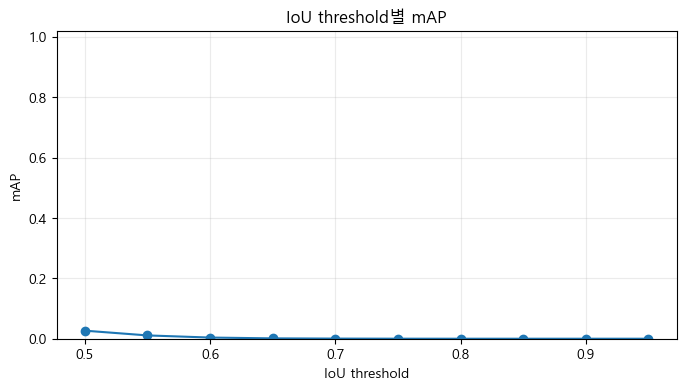

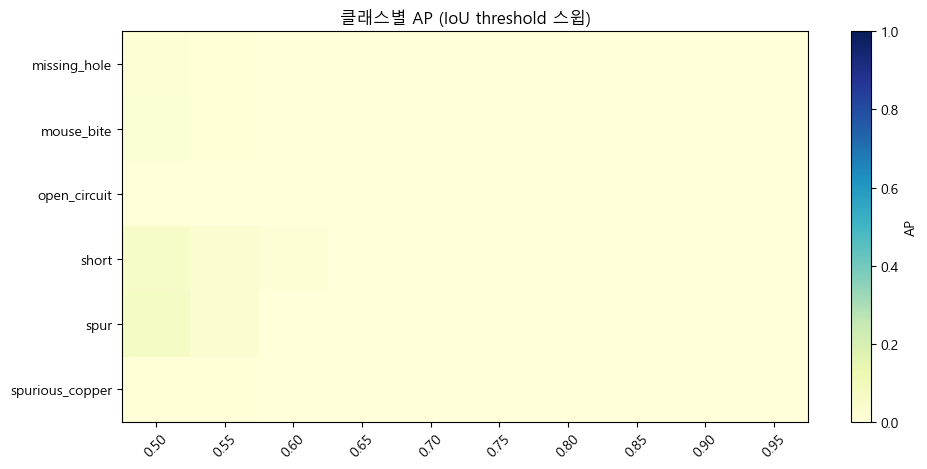

In [5]:
# 시각화 1: IoU threshold별 mAP
plt.figure(figsize=(8, 4))
plt.plot(map_by_thr["iou_thr"], map_by_thr["mAP"], marker="o")
plt.title("IoU threshold별 mAP")
plt.xlabel("IoU threshold")
plt.ylabel("mAP")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.show()

# 시각화 2: class x iou AP heatmap
pivot = ap_df.pivot(index="class_name", columns="iou_thr", values="AP")
plt.figure(figsize=(10, 4.8))
im = plt.imshow(pivot.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
plt.colorbar(im, label="AP")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=45)
plt.title("클래스별 AP (IoU threshold 스윕)")
plt.tight_layout()
plt.show()

In [6]:
# 오류 분석: FP 상위 샘플 (IoU=0.5 기준)
fp50 = match_df[(np.isclose(match_df["iou_thr"], 0.5)) & (match_df["match_type"] == "FP")].copy()
fp50 = fp50.sort_values("conf", ascending=False)

display(fp50.head(20))

# 클래스별 FP 비율
m50 = match_df[np.isclose(match_df["iou_thr"], 0.5)].copy()
ratio = m50.groupby(["class_name", "match_type"]).size().unstack(fill_value=0)
ratio["fp_rate"] = ratio.get("FP", 0) / (ratio.sum(axis=1) + 1e-12)
display(ratio.sort_values("fp_rate", ascending=False))

,image_id,class_id,class_name,conf,iou_best,match_type,iou_thr
261,l_light_09_missing_hole_10_1_600,2,missing_hole,0.989148,0.187107,FP,0.5
647,l_light_09_spurious_copper_01_3_600,5,spurious_copper,0.987699,0.350626,FP,0.5
648,l_light_05_spurious_copper_08_3_600,5,spurious_copper,0.985633,0.000000,FP,0.5
262,l_light_12_missing_hole_05_1_600,2,missing_hole,0.983834,0.232071,FP,0.5
649,l_light_06_spurious_copper_10_2_600,5,spurious_copper,0.983630,0.396352,FP,0.5
524,l_light_08_open_circuit_05_2_600,4,open_circuit,0.983618,0.000000,FP,0.5
263,l_light_12_missing_hole_09_1_600,2,missing_hole,0.982548,0.245295,FP,0.5
393,l_light_09_short_08_5_600,3,short,0.981969,0.187282,FP,0.5
0,l_light_10_mouse_bite_02_4_600,0,mouse_bite,0.980929,0.412483,FP,0.5
126,l_light_10_spur_02_1_600,1,spur,0.980628,0.056703,FP,0.5


match_type,FP,TP,fp_rate
class_name,,,
open_circuit,122,1,0.991870
spurious_copper,125,6,0.954198
mouse_bite,114,10,0.919355
missing_hole,119,13,0.901515
spur,120,17,0.875912
short,108,23,0.824427


In [7]:
# 리포트 저장
ap_df.to_csv(OUT_DIR / "ap_by_class_iou.csv", index=False, encoding="utf-8-sig")
map_by_thr.to_csv(OUT_DIR / "map_by_iou_threshold.csv", index=False, encoding="utf-8-sig")
match_df.to_csv(OUT_DIR / "match_details.csv", index=False, encoding="utf-8-sig")

summary = pd.DataFrame([
    {"metric": "mAP@0.50", "value": map50},
    {"metric": "mAP@0.50:0.95", "value": map5095},
    {"metric": "num_predictions", "value": len(preds)},
    {"metric": "num_gt_boxes", "value": sum(len(v) for v in gt.values())},
])
summary.to_csv(OUT_DIR / "summary_metrics.csv", index=False, encoding="utf-8-sig")

display(summary)
print("저장 완료:")
for fn in [
    "ap_by_class_iou.csv",
    "map_by_iou_threshold.csv",
    "match_details.csv",
    "summary_metrics.csv",
]:
    print("-", OUT_DIR / fn)

,metric,value
0,mAP@0.50,0.026675
1,mAP@0.50:0.95,0.004318
2,num_predictions,778.000000
3,num_gt_boxes,581.000000


저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\auto_eval_report\ap_by_class_iou.csv
- C:\MyCursorLab\10_프로젝트\outputs\auto_eval_report\map_by_iou_threshold.csv
- C:\MyCursorLab\10_프로젝트\outputs\auto_eval_report\match_details.csv
- C:\MyCursorLab\10_프로젝트\outputs\auto_eval_report\summary_metrics.csv


## 사용 가이드

1. `PRED_PATH`를 실제 추론 결과 파일로 변경
2. 노트북을 위에서 아래로 실행
3. `outputs/auto_eval_report/`의 CSV 리포트 확인

### 권장 체크리스트
- 좌표가 0~1 정규화인지 확인
- `image_id`가 GT 파일 stem과 일치하는지 확인
- class_id 체계가 동일한지 확인
- NMS 이후 결과를 입력했는지 확인

## 실습 과제

1. confidence threshold를 0.3/0.5/0.7로 바꿔 FP 변화량 비교
2. 클래스별 score calibration 전/후 mAP 비교
3. PR 곡선을 클래스별로 저장하는 자동화 함수 추가
4. 실험별 리포트를 날짜+모델명 폴더로 버전 관리

---

### 한 줄 정리
이 노트북은 **예측 파일만 바꿔 반복 평가 가능한 자동 리포팅 템플릿**입니다.